In [1]:
import scanpy as sc
import matplotlib as mpl


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [51]:

adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/epithelial.h5ad')
# l_adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/lymphoid.h5ad')

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
for celltype in adata.obs['Prelim annotation'].unique():
    print(celltype)

## Dotplots for rare cell types

In [52]:
adata.var

,gene_id,gene_symbol,mt,ribo,hb,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,feature_is_filtered
ENSG00000000003,ENSG00000000003,TSPAN6,False,False,False,130826,195140,0.094287,0.090103,94.224985,318599,12.671692,False,0.076050,1.038674,-1.111607,False
ENSG00000000005,ENSG00000000005,TNMD,False,False,False,3135,4878,0.001594,0.001593,99.855639,5387,8.591930,False,0.001454,0.667250,-0.527142,False
ENSG00000000419,ENSG00000000419,DPM1,False,False,False,254820,329289,0.129758,0.122003,90.254951,438457,12.991019,False,0.150211,1.092318,inf,False
ENSG00000000457,ENSG00000000457,SCYL3,False,False,False,136455,175516,0.060628,0.058861,94.805742,204864,12.230107,False,0.063990,1.189661,0.017007,False
ENSG00000000460,ENSG00000000460,C1orf112,False,False,False,57454,70285,0.024555,0.024258,97.919971,82971,11.326258,False,0.025647,1.210943,-0.018293,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288380,ENSG00000288380,CRIPAK,False,False,False,16897,20886,0.006547,0.006525,99.381895,22122,10.004373,False,0.008141,0.529624,-0.047372,False
ENSG00000288398,ENSG00000288398,AL109627.1,False,False,False,2644,3151,0.000945,0.000944,99.906749,3193,8.069029,False,0.001483,0.521270,0.030542,False
ENSG00000288436,ENSG00000288436,AC024558.2,False,False,False,1438,1631,0.000532,0.000532,99.951732,1799,7.495542,False,0.001226,0.269041,-0.007030,False
ENSG00000288459,ENSG00000288459,AL512357.2,False,False,False,2888,3349,0.001025,0.001024,99.900889,3462,8.149891,False,0.001375,0.174228,0.044378,False


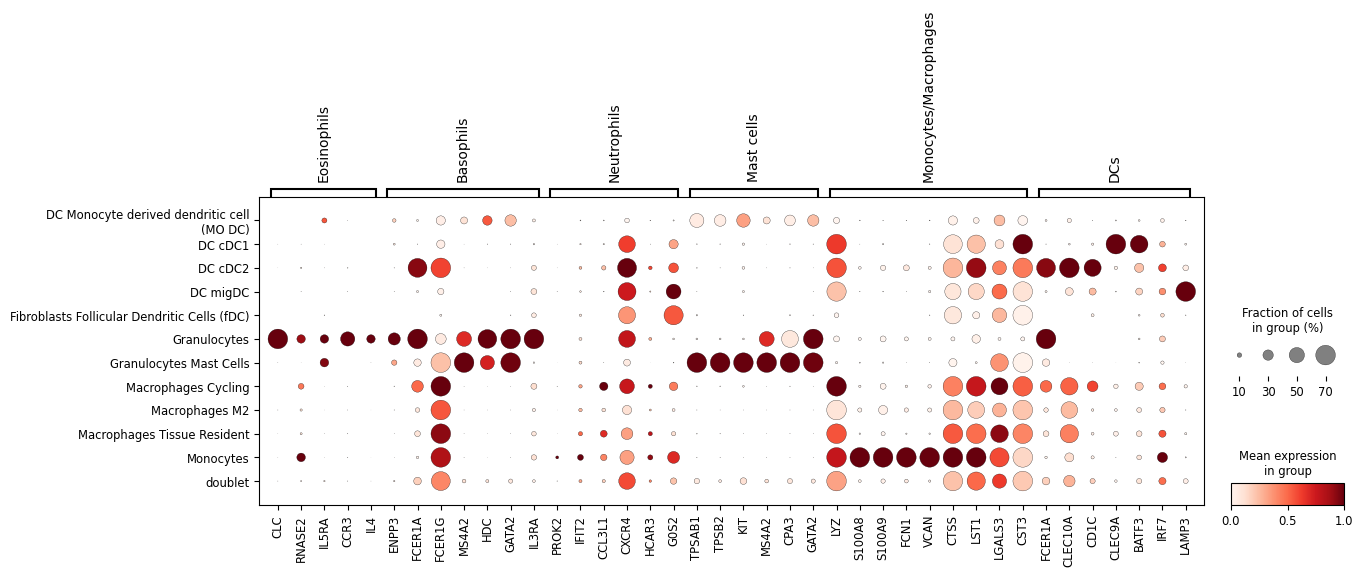

In [19]:
type_col = "Prelim annotation"

eos_markers = ["CLC", "RNASE2", "IL5RA", "CCR3", "IL4"]
baso_markers = ["ENPP3","FCER1A", "FCER1G", "MS4A2", "HDC", "GATA2", "IL3RA"]
neut_markers = ["PROK2", "IFIT2", "CCL3L1", "CXCR4", "HCAR3", "G0S2"]
mast_markers = ["TPSAB1", "TPSB2", "KIT", "MS4A2", "CPA3", "GATA2"]
mono_mac_markers = ["LYZ", "S100A8", "S100A9", "FCN1", "VCAN", "CTSS", "LST1", "LGALS3", "CST3"]
dc_markers = ["FCER1A", "CLEC10A", "CD1C", "CLEC9A", "BATF3", "IRF7", "LAMP3"]

marker_panels = {
    "Eosinophils": eos_markers,
    "Basophils": baso_markers,
    "Neutrophils": neut_markers,
    "Mast cells": mast_markers,
    "Monocytes/Macrophages": mono_mac_markers,
    "DCs": dc_markers,
}

sym_col = "gene_symbol"
sym = adata.var[sym_col].astype(str)

marker_panels = {k: [g for g in v if (sym == g).any()] for k, v in marker_panels.items()}
marker_panels = {k: v for k, v in marker_panels.items() if len(v) > 0}

mpl.rcdefaults()
mpl.rcParams["figure.figsize"] = (9, 4)

if len(marker_panels) == 0:
    raise ValueError("None of the marker genes were found in adata.var_names")

# Make dotplot with explicit figsize to avoid the gridspec error
sc.pl.dotplot(
    adata,
    var_names=marker_panels,
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(14, 4),
    show=True,
)

In [ ]:
type_col = "Prelim annotation"

eos_markers = ["CLC", "RNASE2", "IL5RA", "CCR3", "IL4"]
baso_markers = ["ENPP3","FCER1A", "FCER1G", "MS4A2", "HDC", "GATA2", "IL3RA"]
neut_markers = ["PROK2", "IFIT2", "CCL3L1", "CXCR4", "HCAR3", "G0S2"]
mast_markers = ["TPSAB1", "TPSB2", "KIT", "MS4A2", "CPA3", "GATA2"]
mono_mac_markers = ["LYZ", "S100A8", "S100A9", "FCN1", "VCAN", "CTSS", "LST1", "LGALS3", "CST3"]
dc_markers = ["FCER1A", "CLEC10A", "CD1C", "CLEC9A", "BATF3", "IRF7", "LAMP3"]

marker_panels = {
    "Eosinophils": eos_markers,
    "Basophils": baso_markers,
    "Neutrophils": neut_markers,
    "Mast cells": mast_markers,
    "Monocytes/Macrophages": mono_mac_markers,
    "DCs": dc_markers,
}

sym_col = "gene_symbol"
sym = adata.var[sym_col].astype(str)

marker_panels = {k: [g for g in v if (sym == g).any()] for k, v in marker_panels.items()}
marker_panels = {k: v for k, v in marker_panels.items() if len(v) > 0}

mpl.rcdefaults()
mpl.rcParams["figure.figsize"] = (9, 4)

if len(marker_panels) == 0:
    raise ValueError("None of the marker genes were found in adata.var_names")

# Make dotplot with explicit figsize to avoid the gridspec error
sc.pl.dotplot(
    adata,
    var_names=marker_panels,
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(14, 4),
    show=True,
)

In [20]:
adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/stroma.h5ad')
for celltype in adata.obs['Prelim annotation'].unique():
    print(celltype)

doublet
Epithelial
Smooth Muscle Cells (SMC)
Fibroblasts Lamina propria (S1)
vascular endothelial Venular
Fibroblasts Crypt Bottom (S2A)
Fibroblasts Crypt Top (S2B)
vascular endothelial Arteriolar
vascular endothelial Pre venule capillary (PVC)
Fibroblasts Subserosal
Fibroblasts Subepithelial (S2)
vascular endothelial Post arteriole capillary (PAC)
Glia Myenteric Plexus / Type I
Glia Submucosal Plexus / Type I
Pericytes Secretory
Fibroblasts Muscularis Propria
Glia Mucosal/Type III
SMC Inner Muscle Cells
Glia Extra-Ganglionic
lowQ
Fibroblastic reticular cells
Pericytes Angiogenic
SMC Outer Muscle Cells
vascular endothelial
Pericytes Contractile
Glia Intra-Ganglionic
vascular endothelial Lymphatic
vascular endothelial Capillary
vascular endothelial Lacteals
Pericytes Immature
Fibroblasts mLTo Cells (mesenchymal lymphoid tissue organizer cells)
Plasma Cells
Fibroblasts Myofibroblasts
Glia Muscularis propria/Type IV
Fibroblasts Submucosal (aka Crypt Support/Trophocytes/S3)


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


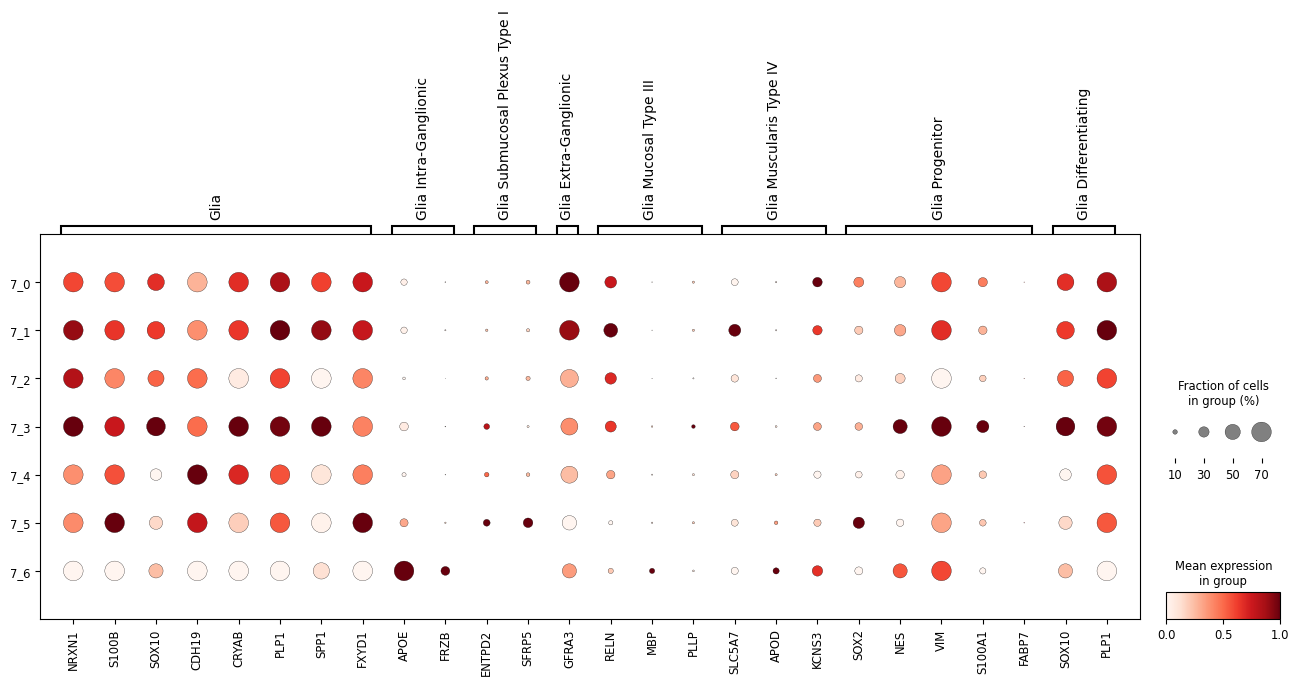

In [28]:


keep_types = [
    "vascular endothelial Venular",
    "vascular endothelial Arteriolar",
    "vascular endothelial Pre venule capillary (PVC)",
    "vascular endothelial Post arteriole capillary (PAC)",
    "vascular endothelial Lymphatic",
    "vascular endothelial Capillary",
    "vascular endothelial Lacteals",
    "Glia Myenteric Plexus / Type I",
    "Glia Submucosal Plexus / Type I",
    "Glia Mucosal/Type III",
    "Glia Extra-Ganglionic",
    "Glia Intra-Ganglionic",
    "Glia Muscularis propria/Type IV",
]

adata_sub = adata[adata.obs[type_col].isin(keep_types)].copy()

sym = adata_sub.var[sym_col].astype(str)
present = set(sym.values)

glia_panels = {
    "Glia": ["NRXN1", "S100B", "SOX10", "CDH19", "CRYAB", "PLP1", "SPP1", "FXYD1"],
    "Glia Intra-Ganglionic": ["APOE", "FRZB"],
    "Glia Myenteric Plexus Type I": ["CACLB"],
    "Glia Submucosal Plexus Type I": ["ENTPD2", "SFRP5"],
    "Glia Extra-Ganglionic": ["GFRA3"],
    "Glia Mucosal Type III": ["RELN", "MBP", "PLLP"],
    "Glia Muscularis Type IV": ["SLC5A7", "APOD", "KCNS3"],
    "Glia Progenitor": ["SOX2", "NES", "VIM", "S100A1", "FABP7"],
    "Glia Differentiating": ["SOX10", "PLP1"],
}

endo_meso_panels = {
    "Endothelial core": ["PECAM1", "CDH5", "CLDN5"],
    "Arteriolar": ["SEMA3G", "MGP", "IGFBP4"],
    "Capillary": ["CD36", "RAMP2", "IGFBP7"],
    "PAC": ["RGCC", "FCN3"],
    "PVC": ["ICAM1", "LITAF"],
    "Venular": ["ACKR1", "MADCAM1", "SELP"],
    "Lymphatic core": ["PROX1", "PDPN"],
    "Lacteals": ["FABP1", "PLVAP"],
    "Mesothelial": ["WT1", "MSLN"],
    "LEC Ceiling": ["ACKR4", "NT5E", "CAV1"],
    "LEC Floor": ["MADCAM1", "ITGA2B", "CCL20"],
    "LEC Sinus": ["STAB2", "LYVE1", "MARCO"],
    "LEC Medullary sinus": ["MRC1", "STAB2", "MARCO"],
    "LEC Cortical sinus": ["ACKR4", "STAB1", "CCRL2"],
}
glia_panels = {k: [g for g in v if g in present] for k, v in glia_panels.items()}
glia_panels = {k: v for k, v in glia_panels.items() if len(v) > 0}

endo_meso_panels = {k: [g for g in v if g in present] for k, v in endo_meso_panels.items()}
endo_meso_panels = {k: v for k, v in endo_meso_panels.items() if len(v) > 0}

glia_types = [t for t in keep_types if t.startswith("Glia")]
endo_types = [t for t in keep_types if t.startswith("vascular endothelial")]

adata_glia = adata_sub[adata_sub.obs[type_col].isin(glia_types)].copy()
adata_endo = adata_sub[adata_sub.obs[type_col].isin(endo_types)].copy()

# Make dotplot with explicit figsize to avoid the gridspec error
sc.pl.dotplot(
    adata_glia,
    var_names=glia_panels,
    groupby='leiden_lineage_l2',
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(16, 5),
    show=True,
)

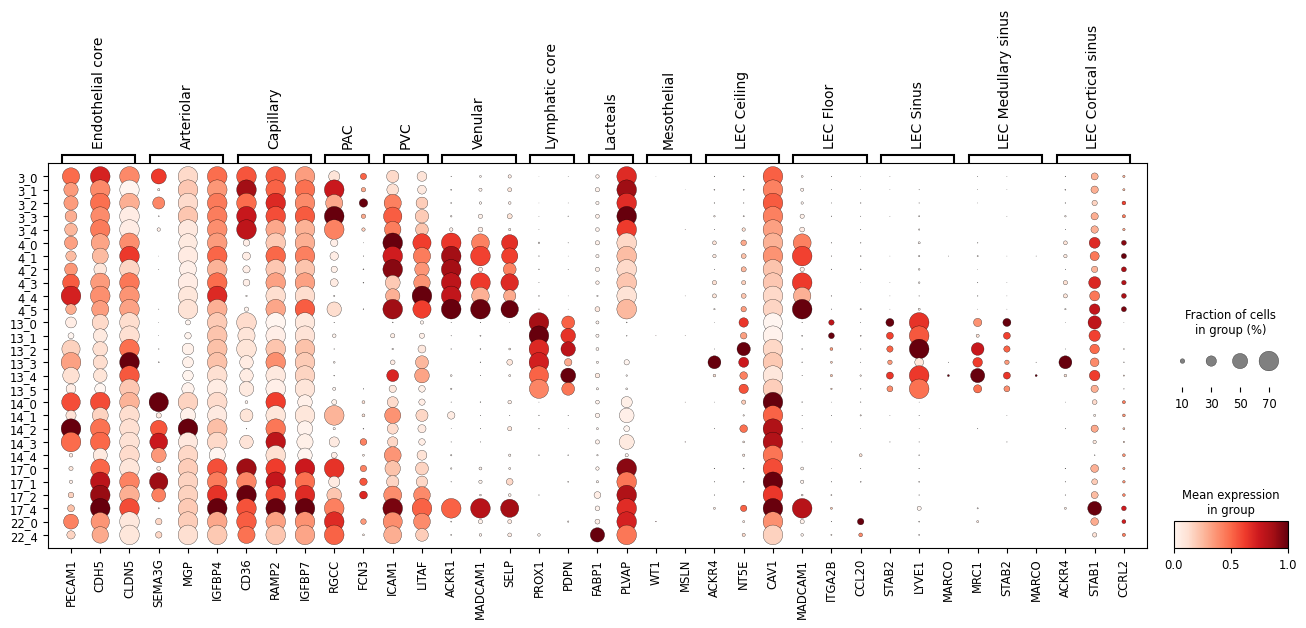

In [30]:
sc.pl.dotplot(
    adata_endo,
    var_names=endo_meso_panels,
    groupby='leiden_lineage_l2',
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(16, 5),
    show=True,
)

## Searching for rare cell types yet undescribed in scRNA data

### Subset to relevant parent celltype

In [28]:
adata_sub = adata[adata.obs['cell_type_atlas'].isin(['Enteroendocrine Cells (EEC)', 'EEC Progenitor', 'EEC L Cells (PYY+)', 'EEC Enterochromaffin Cells', 'EEC N Cells', 'EEC S Cells (SCT+)'])].copy()
adata_sub

AnnData object with n_obs × n_vars = 2845 × 36353
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'closest_GCA_celltype_x', 'cell_type_atlas', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'cont

### recalculate UMAP within parent celltype

In [29]:
sc.pp.pca(adata_sub)
sc.pp.neighbors(adata_sub)
sc.tl.umap(adata_sub)


### show putative marker genes on resulting subset UMAP

In [10]:
adata.var

,gene_id,gene_symbol,mt,ribo,hb,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,feature_is_filtered
ENSG00000000003,ENSG00000000003,TSPAN6,False,False,False,130826,195140,0.094287,0.090103,94.224985,318599,12.671692,False,0.076050,1.038674,-1.111607,False
ENSG00000000005,ENSG00000000005,TNMD,False,False,False,3135,4878,0.001594,0.001593,99.855639,5387,8.591930,False,0.001454,0.667250,-0.527142,False
ENSG00000000419,ENSG00000000419,DPM1,False,False,False,254820,329289,0.129758,0.122003,90.254951,438457,12.991019,False,0.150211,1.092318,inf,False
ENSG00000000457,ENSG00000000457,SCYL3,False,False,False,136455,175516,0.060628,0.058861,94.805742,204864,12.230107,False,0.063990,1.189661,0.017007,False
ENSG00000000460,ENSG00000000460,C1orf112,False,False,False,57454,70285,0.024555,0.024258,97.919971,82971,11.326258,False,0.025647,1.210943,-0.018293,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288380,ENSG00000288380,CRIPAK,False,False,False,16897,20886,0.006547,0.006525,99.381895,22122,10.004373,False,0.008141,0.529624,-0.047372,False
ENSG00000288398,ENSG00000288398,AL109627.1,False,False,False,2644,3151,0.000945,0.000944,99.906749,3193,8.069029,False,0.001483,0.521270,0.030542,False
ENSG00000288436,ENSG00000288436,AC024558.2,False,False,False,1438,1631,0.000532,0.000532,99.951732,1799,7.495542,False,0.001226,0.269041,-0.007030,False
ENSG00000288459,ENSG00000288459,AL512357.2,False,False,False,2888,3349,0.001025,0.001024,99.900889,3462,8.149891,False,0.001375,0.174228,0.044378,False


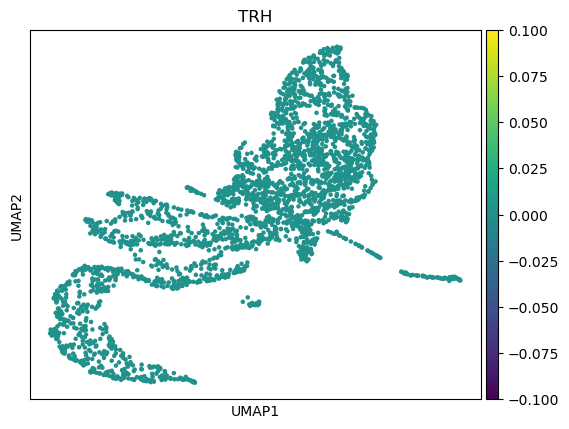

In [11]:
sc.pl.umap(adata_sub, color=['TRH'], gene_symbols='gene_symbol')


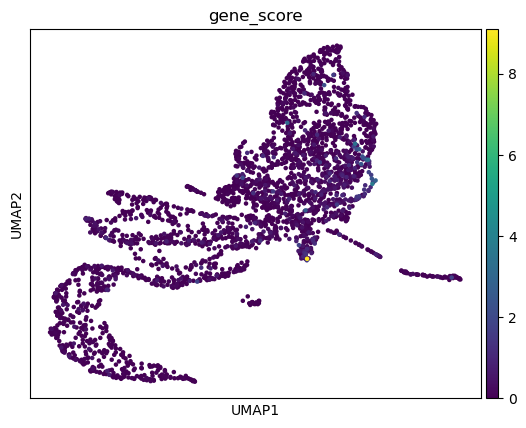

In [12]:
genes = ['SYT10','KLHL4','DGKI','CDH10','NCAM2','IL1RAP','GHR','CDH4','SRRM4','CNTN4']
adata_sub.obs['gene_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(genes)].X.mean(axis=1)
sc.pl.umap(adata_sub, color='gene_score')


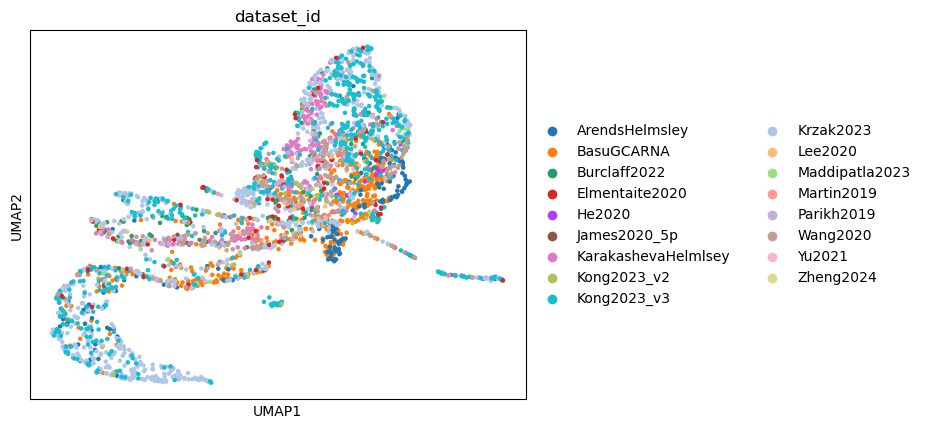

In [13]:
sc.pl.umap(adata_sub, color=['dataset_id'])


In [14]:
adata_sub.obs['tissue_ontology_term'].value_counts()

tissue_ontology_term
ileum               2088
ascending colon      460
rectum                78
transverse colon      42
duodenum              40
jejunum               38
colon                 32
descending colon      21
small intestine       20
sigmoid colon         19
caecum                 7
Name: count, dtype: int64

### EEC subtypes per dataset recovery

In [5]:
import numpy as np
import matplotlib.pyplot as plt


X = adata.X

mu = np.array(X.mean(axis=0)).ravel()

# compute std for sparse: sqrt(E[x^2] - (E[x])^2)
mean_sq = np.array(X.power(2).mean(axis=0)).ravel()
var = mean_sq - mu**2
var[var < 0] = 0
sd = np.sqrt(var)
sd[sd == 0] = 1

adata.layers["zscore"] = X.multiply(1 / sd) - mu / sd

/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'zscore' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


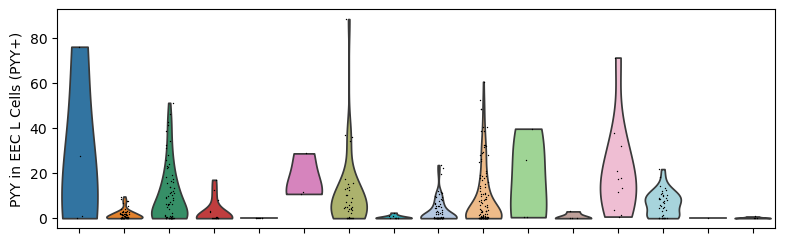

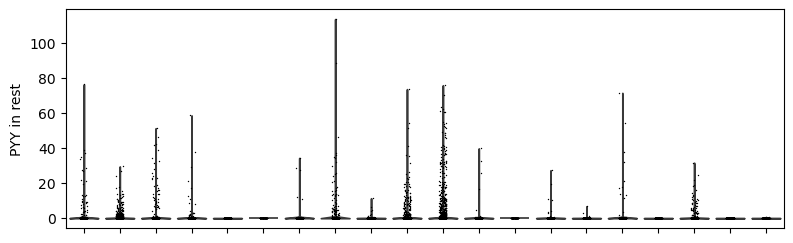

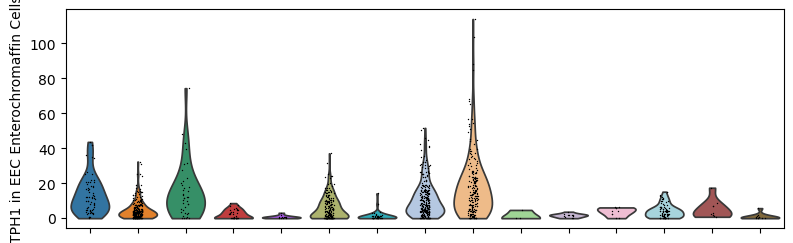

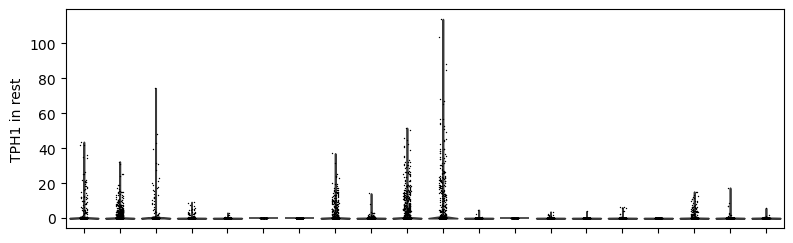

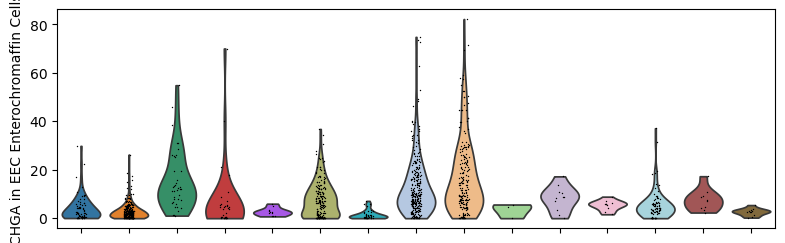

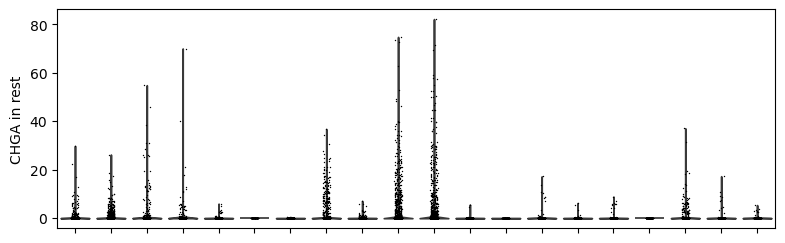

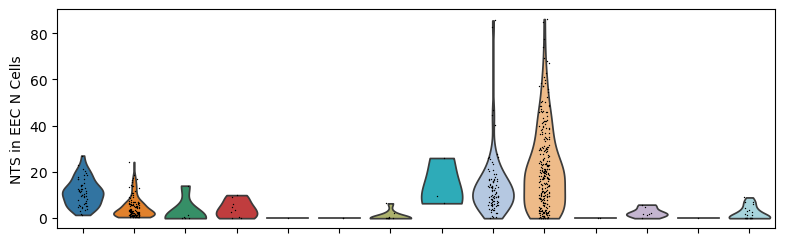

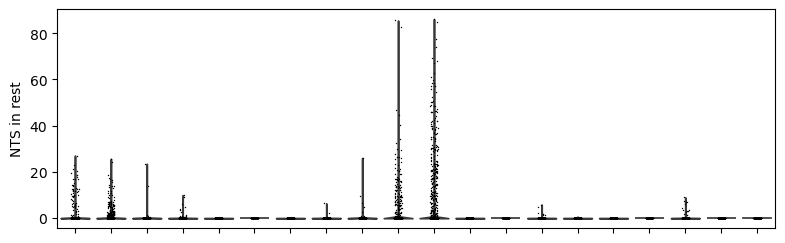

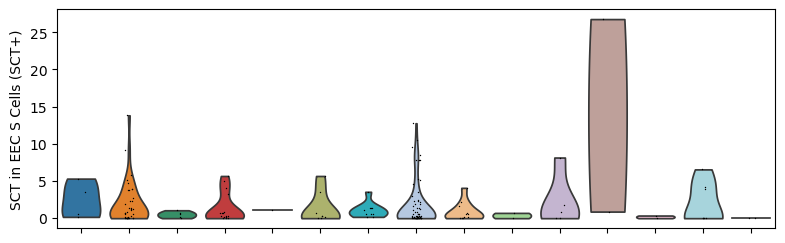

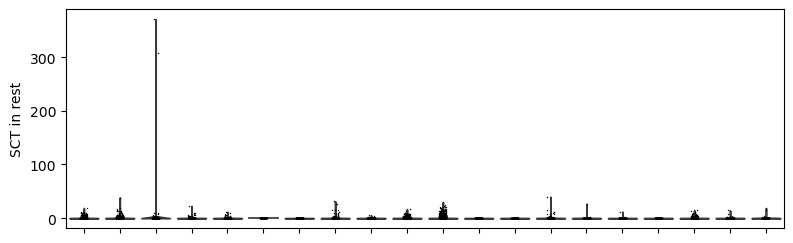

In [17]:
from matplotlib import rcParams

rcParams["figure.figsize"] = (8,3)

# inputs
celltypes = [
    "EEC L Cells (PYY+)",
    "EEC Enterochromaffin Cells",
    "EEC N Cells",
    "EEC S Cells (SCT+)",
]
markers = {
    "EEC L Cells (PYY+)": ["PYY"],
    "EEC Enterochromaffin Cells": ["TPH1", "CHGA"],
    "EEC N Cells": ["NTS"],
    "EEC S Cells (SCT+)": ["SCT"],
}

if "gene_symbol" in adata.var.columns:
    symbol_to_var = dict(zip(adata.var["gene_symbol"], adata.var_names))
else:
    symbol_to_var = {g: g for g in adata.var_names}

def get_var(sym):
    return symbol_to_var.get(sym, None)

import matplotlib.pyplot as plt  # needed for tick edits

def hide_ticks_current_fig():
    fig = plt.gcf()
    for ax in fig.axes:
        ax.set_xticklabels([])
        ax.set_xlabel("")

for ct in celltypes:
    ad_ct = adata[adata.obs["Prelim annotation"] == ct].copy()
    # ad_rest = adata[adata.obs["Prelim annotation"] != ct].copy()

    for sym in markers[ct]:
        var = get_var(sym)
        if var is None:
            print("missing", sym)
            continue

        axs = sc.pl.violin(
            ad_ct,
            keys=[var],
            groupby="dataset_id",
            use_raw=False,
            layer="zscore",
            rotation=None,
            # figsize=(8,3),
            show=False,
            ylabel=f"{sym} in {ct}",
        )
        hide_ticks_current_fig()
        # sc.pl.show()

        axs = sc.pl.violin(
            adata,
            keys=[var],
            groupby="dataset_id",
            use_raw=False,
            layer="zscore",
            rotation=None,
            # figsize=(8,3),
            show=False,
            ylabel=f"{sym} in rest",
        )
        hide_ticks_current_fig()
        # sc.pl.show()


### Secretory - bicarbonate producers

In [16]:
for celltype in adata.obs['Prelim annotation'].unique():
    print(celltype)

Cycling TA
Absorptive TA
Colonocytes Early
Secretory Goblet Cells
Colonocytes Laminin
lowQ
Colonocytes
Secretory TA
Colonocytes Late
Follicle associated enterocyte (FAE)
Enterocytes Early
Secretory Tuft Cells
Microfold Cells (M Cells)
Transiently Amplifying Cells (TA)
Epithelial Stem Cells (LGR5+)
Enterocytes
Colonocytes BEST4
EEC L Cells (PYY+)
EEC Enterochromaffin Cells
Enteroendocrine Cells (EEC)
EEC Progenitor
Enterocytes Late
EEC N Cells
Enterocytes BEST4
Secretory Paneth Cells
Plasma Cells
doublet
EEC S Cells (SCT+)
Monocytes


In [17]:
adata_sub = adata[adata.obs['cell_type_atlas'].isin(['Secretory Goblet Cells', 'Secretory TA', 'Enterocytes', 
                                                     'Enterocytes Early', 'Enterocytes Late', 
                                                     'Colonocytes', 'Colonocytes Early', 'Colonocytes Late', 
                                                     'Colonocytes BEST4', 'Colonocytes Laminin', 'Secretory Tuft Cells',
                                                     'Secretory Paneth Cells'])].copy()

sc.pp.pca(adata_sub); sc.pp.neighbors(adata_sub); sc.tl.umap(adata_sub)

In [18]:
adata_sub.obs['tissue_ontology_term'].value_counts()

tissue_ontology_term
ileum                 96502
ascending colon       29115
transverse colon       3762
sigmoid colon          3733
colon                  3663
duodenum               3475
rectum                 2935
jejunum                2593
small intestine        1735
descending colon       1115
caecum                  532
vermiform appendix       18
Name: count, dtype: int64

In [49]:
bicarb_score = ['SLC26A3', 'SLC4A4', 'SLC4A10', 'CFTR', 'CA2', 'CA4', 'CA12', 'GUCA2A', 'GUCA2B', 'BEST4', 'OTOP2', 'PIGR', 'MUC6']
brunner_genes = ['MUC6', 'TFF2', 'SLC26A3', 'CA12', 'AQP5']
brunner_genes_josh = ['MUC6','PGC','TFF2','HDAC9','TFF3','AQP5']
other_gland_genes = ['MUC5AC','ANXA10','LYZ','REG4','CAPN8']
inflame_score = [
    "MUC6",    # pyloric‑gland mucin marker
    "PGC",     # pepsinogen C
    "AQP5",    # aquaporin 5
    "BPIFB1",  # bactericidal permeability increasing fold–containing B1
    # stem‑cell/inflammatory program genes enriched in INFLAREs
    "SLC12A2",
    "RGMB",
    "LGR5",
    "LEFTY1",
    "REG1A",
    "OLFM4"
]

adata_sub.obs['bicarb_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(genes)].X.mean(axis=1).A1

adata_sub.obs['brunner_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(brunner_genes)].X.mean(axis=1).A1

adata_sub.obs['brunner_josh_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(brunner_genes_josh)].X.mean(axis=1).A1
adata_sub.obs['other_gland_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(other_gland_genes)].X.mean(axis=1).A1

adata_sub.obs['inflame_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(other_gland_genes)].X.mean(axis=1).A1


sc.pl.umap(adata_sub, color='bicarb_score')

sc.pl.umap(adata_sub, color='brunner_score')

sc.pl.umap(adata_sub, color='brunner_josh_score')

sc.pl.umap(adata_sub, color='other_gland_score')

sc.pl.umap(adata_sub, color='inflame_score')

NameError: name 'genes' is not defined

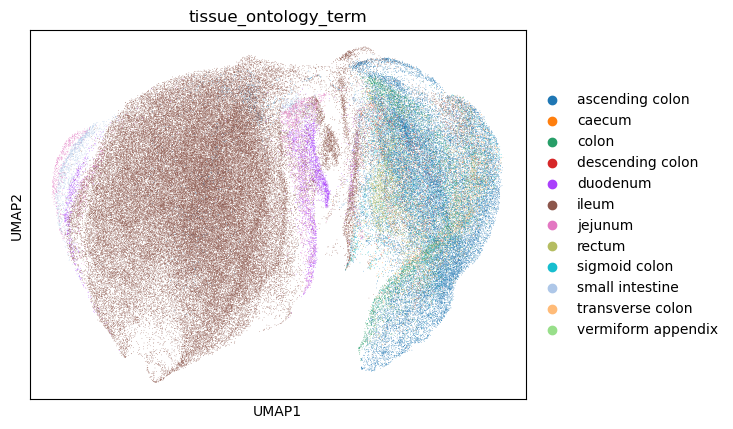

In [20]:
sc.pl.umap(adata_sub, color='tissue_ontology_term')

In [21]:
adata_sub.obs['tissue_free_text'].unique()

['ascending_colon', 'terminal ileum', NaN, 'middle_ileum', 'middle_descending_colon', ..., 'middle_duodenum', 'middle_jejunum', 'middle_ascending_colon', 'ascending colon ', 'Intestine mucosa were freshly sampled at leas...]
Length: 11
Categories (10, object): ['Intestine mucosa were freshly sampled at leas..., 'ascending colon ', 'ascending_colon', 'middle_ascending_colon', ..., 'middle_ileum', 'middle_jejunum', 'middle_transverse_colon', 'terminal ileum']

In [22]:
# sc.pl.umap(adata_sub, color='tissue_ontology_term')

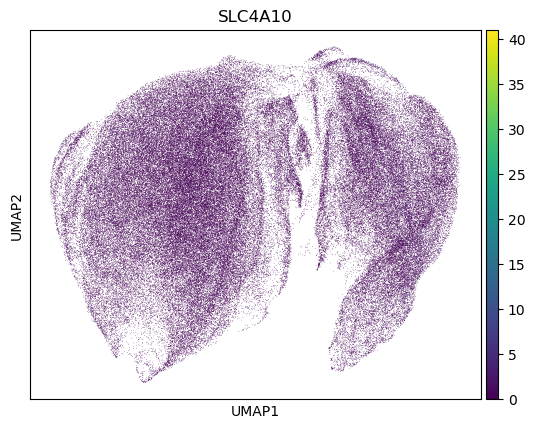

In [23]:
sc.pl.umap(adata_sub, color=['SLC4A10'], gene_symbols='gene_symbol')



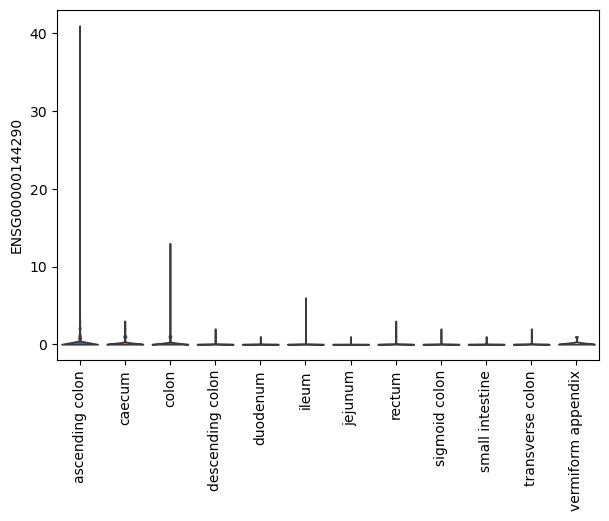

In [24]:
gene = adata_sub.var_names[adata_sub.var['gene_symbol'] == 'SLC4A10'][0]
sc.pl.violin(adata_sub, keys=[gene], groupby='tissue_ontology_term', stripplot=False, rotation=90)

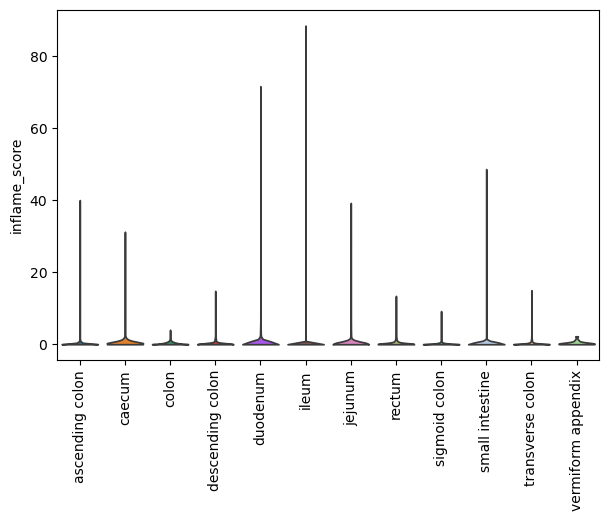

In [25]:
sc.pl.violin(adata_sub, keys=['inflame_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

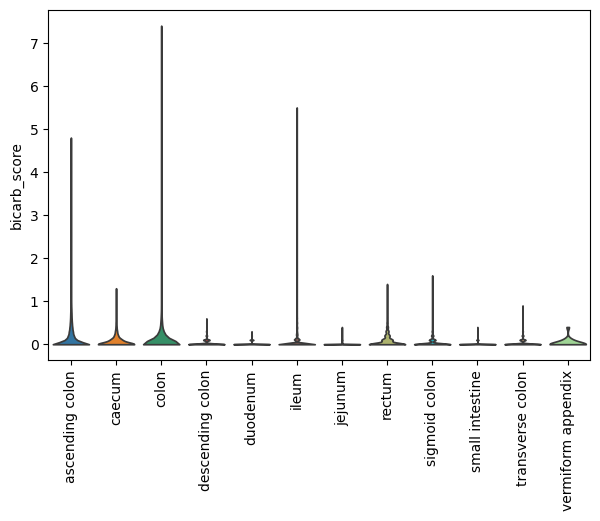

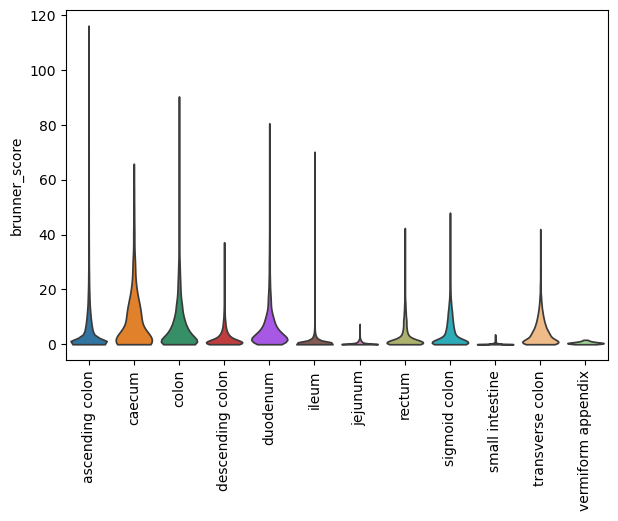

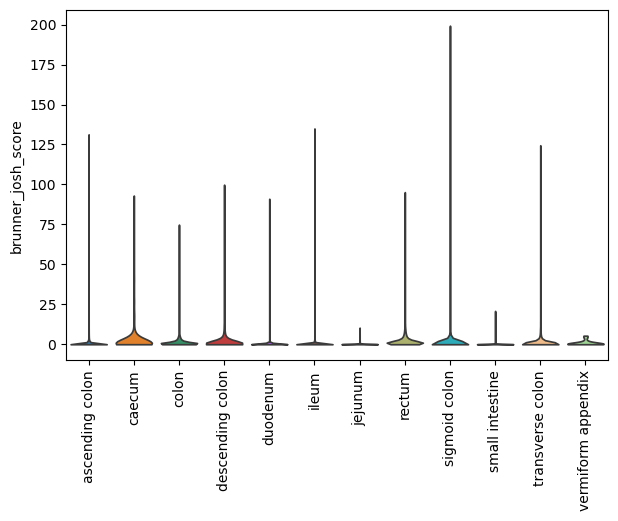

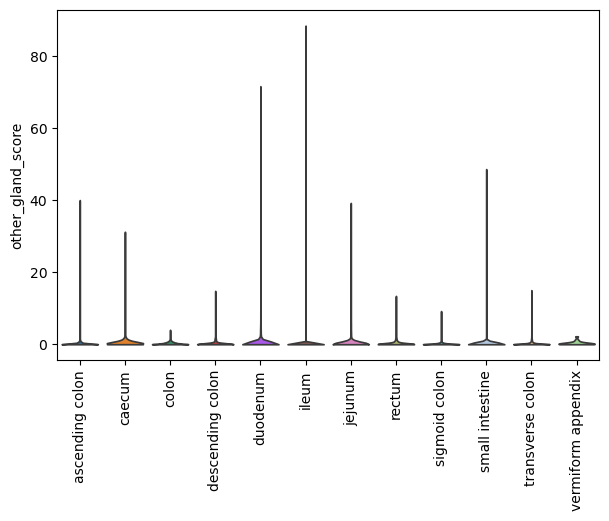

In [26]:
sc.pl.violin(adata_sub, keys=['bicarb_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['brunner_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['brunner_josh_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['other_gland_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

In [27]:
adata.obs[['tissue_ontology_term','radial_tissue_term']].drop_duplicates()

,tissue_ontology_term,radial_tissue_term
0,ascending colon,WM
2121,ileum,WM
69754,ileum,LP
70396,rectum,EPI_LP_MUSC
70900,small intestine,EPI_LP_MUSC
72810,colon,EPI_LP
72952,caecum,EPI_LP_MUSC
73035,transverse colon,EPI_LP_MUSC
73773,sigmoid colon,EPI_LP_MUSC
74169,duodenum,EPI_LP


### sinus endothelial subtypes

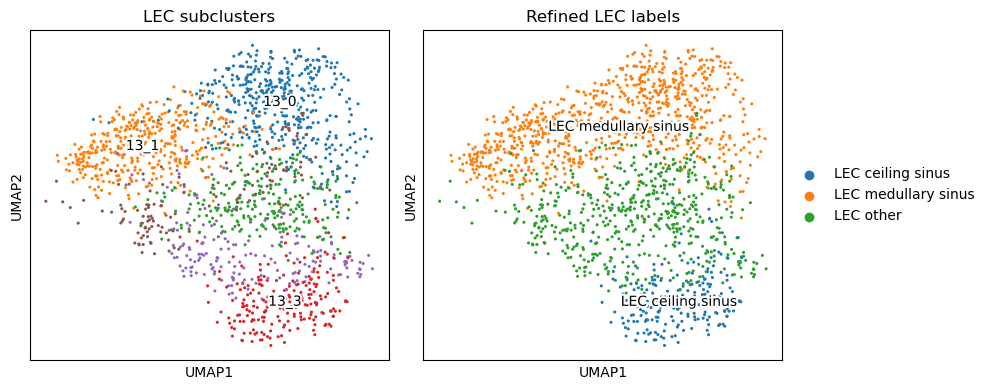

In [44]:
import pandas as pd
import matplotlib.patheffects as pe

type_col = "Prelim annotation"
subclust_col = "leiden_lineage_l2"

lec_label = "vascular endothelial Lymphatic"

ad = adata[adata.obs[subclust_col].astype(str).isin(["13_0", "13_1", "13_2", "13_3", "13_4", "13_5"])].copy()

# Build refined CAP label from the subclusters you named
cap_refined = pd.Series(["LEC other"] * ad.n_obs, index=ad.obs_names)
cap_refined.loc[ad.obs[subclust_col].astype(str).isin(["13_0", "13_1"])] = "LEC medullary sinus"
cap_refined.loc[ad.obs[subclust_col].astype(str).isin(["13_3"])] = "LEC ceiling sinus"
ad.obs["cap_refined_lec"] = cap_refined.values

ref_map = {
    "13_0": "LEC medullary sinus",
    "13_1": "LEC medullary sinus",
    "13_3": "LEC ceiling sinus",
}
ad.obs["cap_refined_lec"] = ad.obs[subclust_col].astype(str).map(ref_map).fillna("LEC other")

def label_on_umap(ad, col, ax, only=None, fontsize=9):
    xy = ad.obsm["X_umap"]
    df = pd.DataFrame(xy, columns=["x", "y"], index=ad.obs_names)
    df[col] = ad.obs[col].astype(str).values
    if only is not None:
        df = df[df[col].isin([str(x) for x in only])]
    cent = df.groupby(col)[["x", "y"]].median()
    for k, r in cent.iterrows():
        t = ax.text(
            float(r["x"]),
            float(r["y"]),
            str(k),
            ha="center",
            va="center",
            fontsize=fontsize,
        )
        t.set_path_effects([pe.Stroke(linewidth=3, foreground="white"), pe.Normal()])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sc.pl.umap(
    ad,
    color=subclust_col,
    ax=axes[0],
    show=False,
    legend_loc=None,
    size=20,
    title="LEC subclusters",
)
label_on_umap(ad, subclust_col, axes[0], only=["13_0", "13_1", "13_3"], fontsize=10)

sc.pl.umap(
    ad,
    color="cap_refined_lec",
    ax=axes[1],
    show=False,
    legend_loc="right margin",
    size=20,
    title="Refined LEC labels",
)
label_on_umap(ad, "cap_refined_lec", axes[1], only=["LEC medullary sinus", "LEC ceiling sinus"], fontsize=10)

plt.tight_layout()
plt.show()

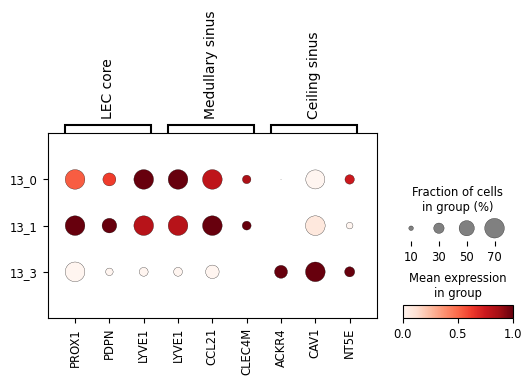

In [48]:
mpl.rcdefaults()

sub = ad[ad.obs[subclust_col].astype(str).isin(["13_0", "13_1", "13_3"])].copy()

markers = {
    "LEC core": ["PROX1", "PDPN", "LYVE1"],
    "Medullary sinus": ["LYVE1", "CCL21", "CLEC4M"],
    "Ceiling sinus": ["ACKR4", "CAV1", "NT5E"],
}

sym = sub.var[sym_col].astype(str)
present = set(sym.values)
markers = {k: [g for g in v if g in present] for k, v in markers.items()}
markers = {k: v for k, v in markers.items() if len(v) > 0}

sc.pl.dotplot(
    sub,
    var_names=markers,
    groupby=subclust_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(6, 2.4),
    show=True,
)